<a href="https://colab.research.google.com/github/toshi039a/retail-demand-forecast/blob/main/%E9%9C%80%E8%A6%81%E4%BA%88%E6%B8%ACPF_20260426.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 小売売上データを用いた需要予測モデル構築

## 1. 概要とデータ読み込み

本分析では、Kaggleの「Store Sales - Time Series Forecasting」データセットを使用する。

本データは、Ecuadorの大手小売チェーンであるCorporación Favoritaの店舗・商品カテゴリ別の日次売上データであり、過去の売上実績や販促情報をもとに、将来の売上を予測することを目的とする。

需要予測は、小売業における在庫管理・発注計画・販促施策の検討において重要な分析テーマであり、売上を事前に予測できれば欠品や過剰在庫のリスクを抑え、より効率的な販売計画につなげることができる。

本Notebookでは、以下の流れで需要予測モデルを構築する。

1. 概要とデータ読み込み
2. 探索的データ分析（EDA）
3. 特徴量エンジニアリング
4. モデリング・評価・モデル解釈
5. まとめ

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 本分析ではKaggleの「Store Sales - Time Series Forecasting」のtrain.csvを使用した。
# 約300万件の時系列データ（2013-01-01 ～ 2017-08-15）であり、
# 54店舗 × 33カテゴリの売上データで構成されている。
# データは以下から取得可能である。
# https://www.kaggle.com/competitions/store-sales-time-series-forecasting
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/需要予測PF/train.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [ ]:
# date列をdatetime型に変換
# 変換できない値はエラーにせず、NaT（datetime版の欠損値）にする
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
# id列を削除
df = df.drop(columns=['id'])

In [ ]:
# datetime型に変更されたことを確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   family       object        
 3   sales        float64       
 4   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 114.5+ MB


### 前処理の考察

- date列は時系列処理のためdatetime型へ変換した。
- id列は識別用の列であり、予測には直接使わないため削除した。
- これにより、EDAと特徴量設計を進める準備が整った。

## 2. 探索的データ分析（EDA)

売上の構造（トレンド・季節性・外部要因）を把握するため、以下のEDAを実施する。

### 2.1 日別売上の可視化

全店舗・全商品カテゴリの売上を日次で集計し、売上の全体推移を確認する。
まずはトレンドや周期性の有無を把握することを目的とする。

In [ ]:
# 日別売上
daily_sales = df.groupby('date')['sales'].sum()
daily_sales

,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229
...,...
2017-08-11,826373.722022
2017-08-12,792630.535079
2017-08-13,865639.677471


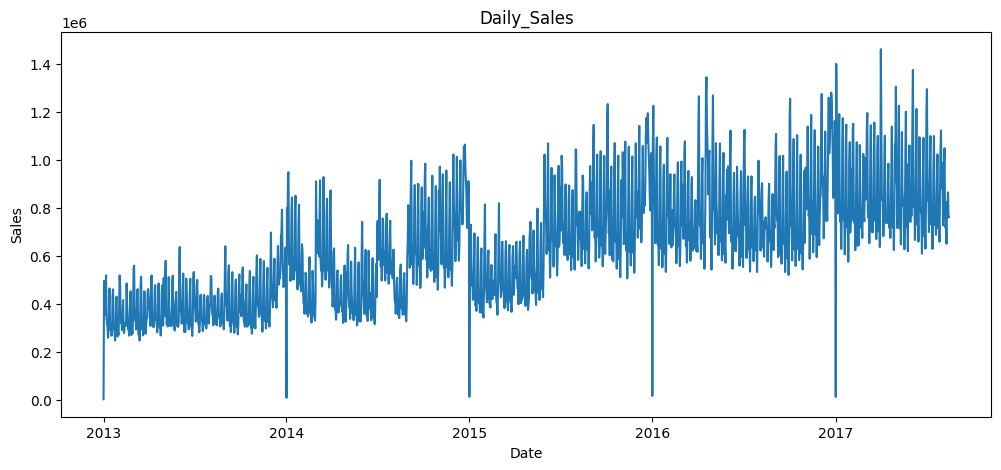

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title('Daily_Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### 日別売上の考察

- 売上には長期的な増加トレンドが見られる。
- 短期的に規則的な変動も確認できる。
- 一部で急激な売上低下が見られ、祝日や休業日などの可能性が考えられる。

### 2.2 自己相関分析（ACF）

日別売上について自己相関を確認し、どのラグで相関が強いかを把握する。

これにより、lag特徴量を設計する際の根拠を得る。

<Figure size 1200x500 with 0 Axes>

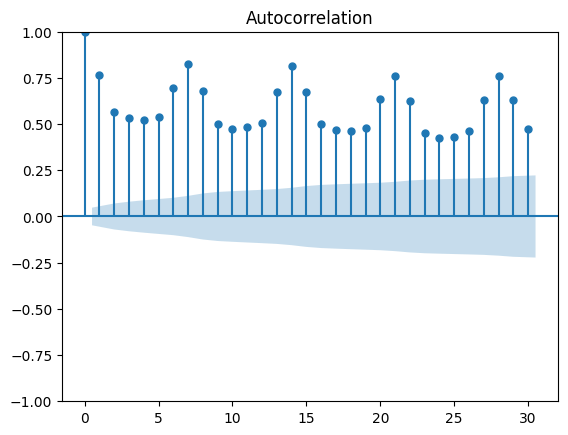

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# 過去何日との相関が強いか確認する
# 7日付近で相関が強ければ、週次性がありそうと考えられる
plt.figure(figsize=(12,5))
plot_acf(daily_sales, lags=30)
plt.show()

### ACFの考察

- 1日および7日周期で自己相関が高く、売上には直近値および週次の周期性が存在することが確認された。
- また、14日以降にも一定の自己相関が見られ、中期的にも過去売上の影響を受けていると考えられる。
- したがって、代表的な時系列特徴量としてlag_1、lag_7、lag_14、および曜日情報day_of_weekを導入する。

### 2.3 STL分解

日別売上をトレンド・季節性・残差に分解し、売上構造を確認する。
ACFで確認した周期性を、時系列分解の観点からも確認する。

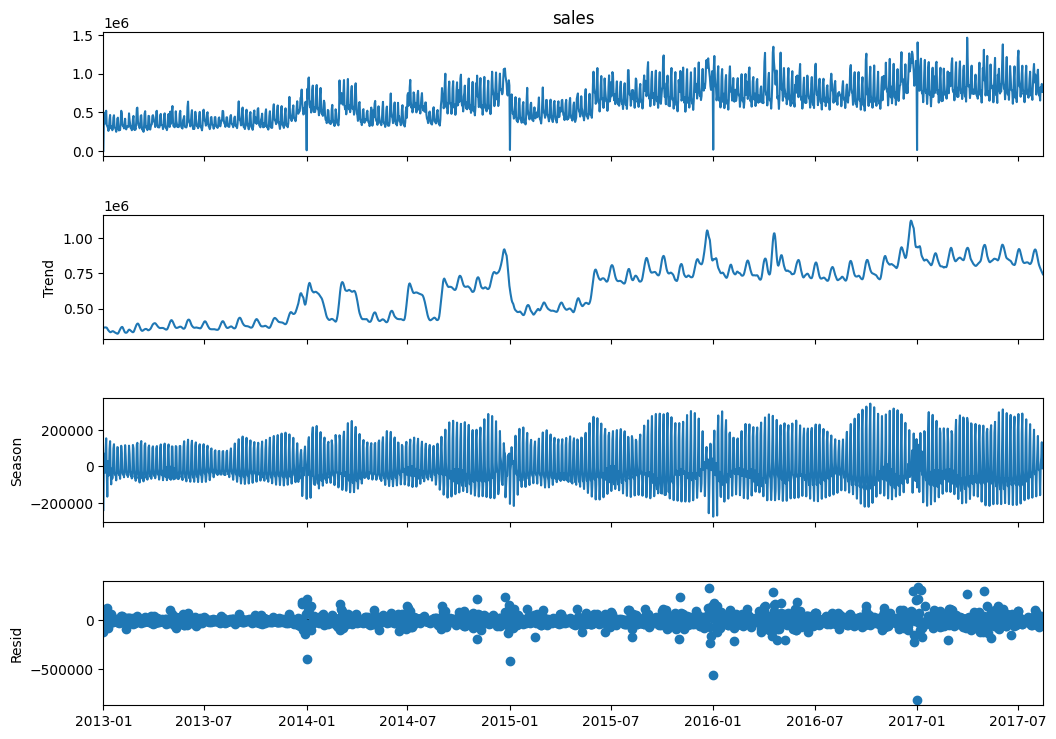

In [ ]:
from statsmodels.tsa.seasonal import STL

# period=7→週次の季節性を仮定
stl = STL(daily_sales, period=7)
result = stl.fit()

# 分解結果をplot
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

### STL分解の考察

- Trend成分から、売上には長期的な増加傾向が確認できる。
- Seasonal成分から、7日周期の規則的な変動が確認できる。
- Residual成分は概ねランダムであり、主要な構造はトレンドと季節性で説明できていると考えられる。

### 2.4 曜日ごとの売上分析

曜日ごとの平均売上を確認し、週次の季節性がどのように現れているかを確認する。

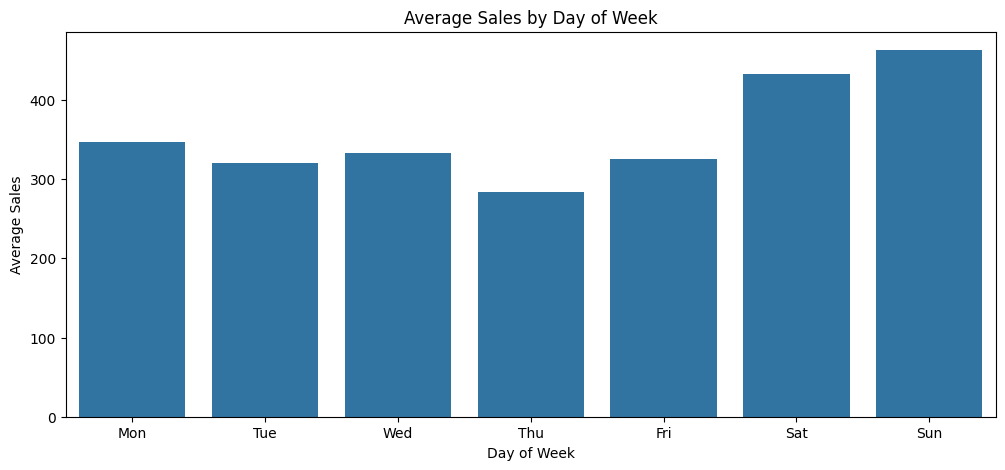

In [ ]:
# 曜日特徴量を作成
df['day_of_week'] = df['date'].dt.dayofweek

# 曜日ごとの平均売上を集計
dow_sales = df.groupby('day_of_week')['sales'].mean().reset_index()

# 曜日ラベルを追加
day_map = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

dow_sales['day_name'] = dow_sales['day_of_week'].map(day_map)

# 曜日ごとの売上を可視化
plt.figure(figsize=(12,5))
sns.barplot(data=dow_sales, x='day_name', y='sales')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()

### 曜日別売上の考察

- 曜日ごとに平均売上に明確な差が見られる。
- 特に土日（Sat, Sun）の売上が高く、平日よりも需要が大きい傾向が確認された。
- 一方で木曜日（Thu）は比較的売上が低い。

このことから、小売需要には曜日要因が強く影響していると考えられる。

したがって、モデルには以下の特徴量を導入する方針とする。
- day_of_week（曜日特徴量）
- lag_7（週次の影響を捉える）

### 2.5 月ごとの売上分析

月単位で売上の傾向を確認する。
小売業では季節性（年末商戦など）が存在するため、補助的な特徴量としてmonthの有効性を検討する。

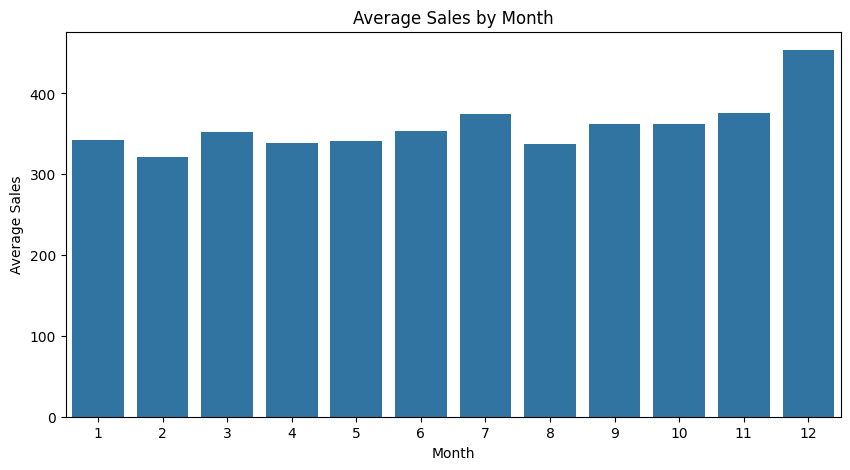

In [ ]:
# 月ごとの平均売上
df['month'] = df['date'].dt.month
month_sales = df.groupby('month')['sales'].mean().reset_index()

#月ごとの売上を可視化
plt.figure(figsize=(10,5))
sns.barplot(data=month_sales, x='month', y='sales')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

### 月別売上の考察

- 月毎の平均売上を確認したところ、特に12月の売上が高く、小売における年末商戦の影響が考えらえる。
- また、2月は他の月と比較して売上がやや低い傾向が見られ、売上には月単位の季節性が存在することが示唆される。
- このことから、補助的な時系列特徴量としてmonthを導入する。

### 2.6 販促（onpromotion）による売上分析

販促の有無が売上に与える影響を確認する。

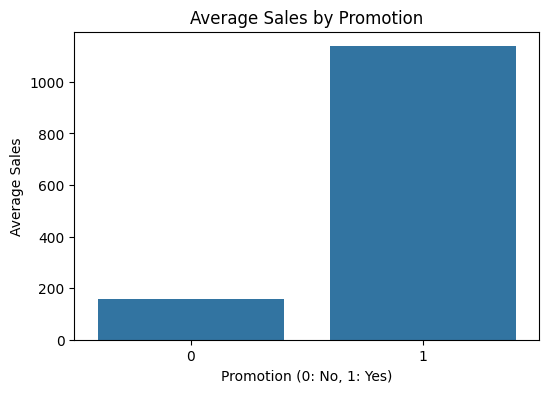

In [ ]:
# onpromotionは「販促商品の数」なので、0: 販促なし、1以上: 販促あり に二値化する
df['is_promo'] = (df['onpromotion'] > 0).astype(int)

# 販促あり/なしで平均売上を比較
promo_sales = df.groupby('is_promo')['sales'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=promo_sales, x='is_promo', y='sales')
plt.title('Average Sales by Promotion')
plt.xlabel('Promotion (0: No, 1: Yes)')
plt.ylabel('Average Sales')
plt.show()

### 販促有無による売上の考察

- 販促の有無による平均売上の違いを確認したところ、販促がある場合に売上が大きく増加する傾向が見られた。
- ただし、販促は売上が見込まれるタイミングで実施されることも多く、単純な因果関係ではなく需要の高まりと同時に発生している可能性がある。
- それでも、販促情報は売上予測において有効な補助シグナルであると考えられる。
- そのため、販促規模を表すonpromotionを主要な販促特徴量として導入し、補助的に販促有無を示すis_promoも作成することにする。

### 2.7 商品カテゴリごとの売上分析

商品カテゴリ（family）ごとに平均売上を集計し、カテゴリごとの売上水準の違いを確認する。

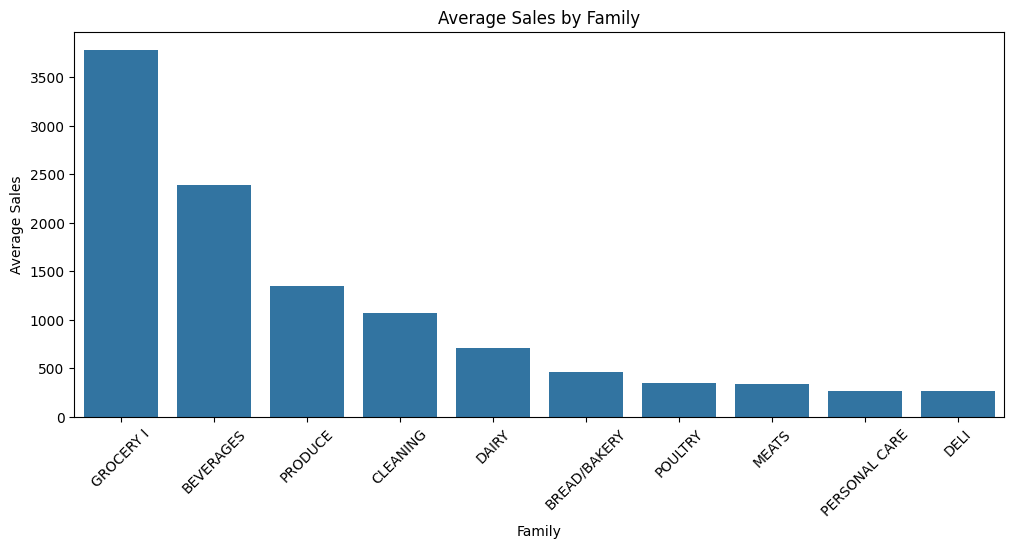

In [ ]:
# カテゴリごとの平均売上を集計
family_sales = df.groupby('family')['sales'].mean().sort_values(ascending=False).reset_index()

# 可視化のために上位10カテゴリに絞る
top10_family_sales = family_sales.head(10)

# 可視化
plt.figure(figsize=(12,5))
sns.barplot(data=top10_family_sales, x='family', y='sales')
plt.title('Average Sales by Family')
plt.xlabel('Family')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()


### 商品カテゴリ別売上の考察

- 商品カテゴリごとに平均売上に大きな差が見られる。
- 特にGROCERY IやBEVERAGESなどのカテゴリが売上を大きく牽引している。
- 一方で、その他のカテゴリは比較的売上水準が低い。

このことから、売上は特定のカテゴリに強く依存しており、
商品カテゴリ（family）は需要予測において重要な特徴量であると考えられる。

したがって、モデルにはカテゴリ変数としてfamilyを組み込むこととする。

### 2.8 EDAまとめ

本EDAにより以下の特徴が確認された。

- 長期的な売上の増加トレンドが存在する。
- 7日周期の強い季節性が存在する。
- 曜日によって売上に差がある。（特に土日が高い）
- 月単位の季節性が存在する。（12月の売上が高い）
- 販促の有無が売上に大きく影響している。
- 商品カテゴリごとに売上水準が大きく異なる。

以上を踏まえ、以下の特徴量を導入する。

- lag特徴量（lag_1, lag_7, lag_14）
- rolling特徴量（rolling_mean_7）
- 曜日特徴量（day_of_week）
- 月特徴量（month）
- 販促特徴量（販促の強さ：onpromotion,販促の有無：is_promo）
- カテゴリ変数（family, store_nbr）

なお、familyおよびstore_nbrについては、それぞれ商品カテゴリ差・店舗差を識別するためのカテゴリ変数として追加した。

## 3. 特徴量エンジニアリング

時系列データの特徴を捉えるため、EDAで確認された傾向に基づき、以下の特徴量を作成する。

- 過去の売上情報（lag特徴量）
- 移動平均（rolling特徴量）
- カレンダー情報（曜日・月）
- 販促情報（販促の有無）

これにより、短期的な変動、週次・月次の季節性、およびトレンドや販促の影響をモデルに取り込む。

また、モデル学習に向けて、欠損値処理およびカテゴリ変数の前処理も併せて実施する。

### 3.1 lag特徴量

In [ ]:
# 時系列順に並べる
df = df.sort_values(['store_nbr', 'family', 'date'])

# 過去の売上を特徴量として作成
df['lag_1'] = df.groupby(['store_nbr', 'family'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store_nbr', 'family'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store_nbr', 'family'])['sales'].shift(14)
df



,date,store_nbr,family,sales,onpromotion,day_of_week,month,is_promo,lag_1,lag_7,lag_14
0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,0,NaN,NaN,NaN
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2,1,0,0.0,NaN,NaN
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,3,1,0,2.0,NaN,NaN
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,4,1,0,3.0,NaN,NaN
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,5,1,0,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2993627,2017-08-11,54,SEAFOOD,0.0,0,4,8,0,2.0,0.0,4.0
2995409,2017-08-12,54,SEAFOOD,1.0,1,5,8,1,0.0,3.0,4.0
2997191,2017-08-13,54,SEAFOOD,2.0,0,6,8,0,1.0,0.0,4.0
2998973,2017-08-14,54,SEAFOOD,0.0,0,0,8,0,2.0,0.0,4.0


- lag_1は前日の売上を表し、短期的な売上の連続性を捉える特徴量である。
- lag_7は1週間前の売上を表し、週次の季節性を反映する。
- lag_14は2週間前の売上を表し、より長めの周期を補完する。

- ACF分析により、lag_1およびlag_7付近で強い自己相関が確認されたため、
短期的な依存関係と週次の季節性の両方を考慮して特徴量を設計した。

### 3.2 rolling特徴量

In [ ]:
# 直近7日間の平均売上を作成
# 当日の売上を含めるとデータリークになるため、shift(1)してからrollingする
df['rolling_mean_7'] = (
    df.groupby(['store_nbr', 'family'])['sales']
      .transform(lambda x: x.shift(1).rolling(7).mean())
)
df

,date,store_nbr,family,sales,onpromotion,day_of_week,month,is_promo,lag_1,lag_7,lag_14,rolling_mean_7
0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,0,NaN,NaN,NaN,NaN
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2,1,0,0.0,NaN,NaN,NaN
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,3,1,0,2.0,NaN,NaN,NaN
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,4,1,0,3.0,NaN,NaN,NaN
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,5,1,0,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2993627,2017-08-11,54,SEAFOOD,0.0,0,4,8,0,2.0,0.0,4.0,3.000000
2995409,2017-08-12,54,SEAFOOD,1.0,1,5,8,1,0.0,3.0,4.0,3.000000
2997191,2017-08-13,54,SEAFOOD,2.0,0,6,8,0,1.0,0.0,4.0,2.714286
2998973,2017-08-14,54,SEAFOOD,0.0,0,0,8,0,2.0,0.0,4.0,3.000000


- rolling_mean_7は各店舗・カテゴリごとに直近7日間の平均売上を表し、短期的なトレンドを捉える特徴量である。
- lag特徴量が「特定の日の情報」であるのに対し、rolling特徴量は「期間の傾向」を表現している。

- 週次の季節性に加えて、直近の売上水準を補足するために導入した。

### 3.3 カレンダー特徴量

In [ ]:
# カレンダー特徴量を作成
# 曜日(0=月曜, 6=日曜)
df['day_of_week'] = df['date'].dt.dayofweek

# 月(1~12)
df['month'] = df['date'].dt.month
df


,date,store_nbr,family,sales,onpromotion,day_of_week,month,is_promo,lag_1,lag_7,lag_14,rolling_mean_7
0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,0,NaN,NaN,NaN,NaN
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2,1,0,0.0,NaN,NaN,NaN
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,3,1,0,2.0,NaN,NaN,NaN
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,4,1,0,3.0,NaN,NaN,NaN
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,5,1,0,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2993627,2017-08-11,54,SEAFOOD,0.0,0,4,8,0,2.0,0.0,4.0,3.000000
2995409,2017-08-12,54,SEAFOOD,1.0,1,5,8,1,0.0,3.0,4.0,3.000000
2997191,2017-08-13,54,SEAFOOD,2.0,0,6,8,0,1.0,0.0,4.0,2.714286
2998973,2017-08-14,54,SEAFOOD,0.0,0,0,8,0,2.0,0.0,4.0,3.000000


- day_of_weekは曜日ごとの売上差を捉える特徴量である。
- EDAにより週次の季節性（特に土日の売上増加）が確認されたため導入した。
- monthは月単位の売上傾向を捉える特徴量であり、年末に向けた需要増加などの季節性を補足する目的で導入した。

### 3.4 販促特徴量

In [ ]:
# onpromotionは「販促商品の数」を表すため、販促の有無を表す二値特徴量を作成する

df['is_promo'] = (df['onpromotion'] > 0).astype(int)
df

,date,store_nbr,family,sales,onpromotion,day_of_week,month,is_promo,lag_1,lag_7,lag_14,rolling_mean_7
0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,0,NaN,NaN,NaN,NaN
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2,1,0,0.0,NaN,NaN,NaN
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,3,1,0,2.0,NaN,NaN,NaN
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,4,1,0,3.0,NaN,NaN,NaN
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,5,1,0,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2993627,2017-08-11,54,SEAFOOD,0.0,0,4,8,0,2.0,0.0,4.0,3.000000
2995409,2017-08-12,54,SEAFOOD,1.0,1,5,8,1,0.0,3.0,4.0,3.000000
2997191,2017-08-13,54,SEAFOOD,2.0,0,6,8,0,1.0,0.0,4.0,2.714286
2998973,2017-08-14,54,SEAFOOD,0.0,0,0,8,0,2.0,0.0,4.0,3.000000


- onpromotionは販促対象商品の数を表す特徴量である。
- 販促規模を表すonpromotionを主要な販促特徴量として使用する。
- また、販促有無をシンプルに表す補助的な特徴量としてis_promoも作成した。
- ただし、is_promoはonpromotionから派生した特徴量であるため、後続の特徴量重要度やSHAPで有効性を確認する。

### 3.5 欠損値処理

In [ ]:
# lag特徴量・rolling特徴量の作成で発生した欠損を削除
df_model = df.dropna().copy()

# 確認
df_model.isna().sum()

,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
day_of_week,0
month,0
is_promo,0
lag_1,0
lag_7,0


### 3.6 カテゴリ変数の処理

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2975940 entries, 24948 to 3000755
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   store_nbr       int64         
 2   family          object        
 3   sales           float64       
 4   onpromotion     int64         
 5   day_of_week     int32         
 6   month           int32         
 7   is_promo        int64         
 8   lag_1           float64       
 9   lag_7           float64       
 10  lag_14          float64       
 11  rolling_mean_7  float64       
dtypes: datetime64[ns](1), float64(5), int32(2), int64(3), object(1)
memory usage: 272.5+ MB


In [ ]:
# LightGBMで扱いやすいようにカテゴリ型に変換
df_model['family'] = df_model['family'].astype('category')
df_model['store_nbr'] = df_model['store_nbr'].astype('category')

## 4. モデリング

ここからは、作成した特徴量を用いて売上予測モデルを構築する。  
まず、単純な予測として「7日前の売上をそのまま予測値とするベースラインモデル」を設定する。  
その上で、LightGBMを用いて予測を行い、MAEで精度を比較する。  

### 4.1 評価方法

時系列データであるため、未来情報の混入を避けるために日付順で学習データとテストデータを分割した。  
本分析では、直近90日をテスト期間、それ以前を学習期間とした。  
評価指標には、予測誤差の大きさを直感的に解釈しやすいMAE（Mean Absolute Error）を用いる。

### 4.2 ベースラインモデル

週次の季節性が強く確認されていたため、ベースラインとして `lag_7` を採用する。  
これは「1週間前と同じ売上になる」と仮定する非常にシンプルな予測であり、  
このベースラインを上回れるかどうかをまず確認する。

In [ ]:
from sklearn.metrics import mean_absolute_error

# 日付順に並べる
df_model = df_model.sort_values(['date', 'store_nbr', 'family']).copy()

# 分割(直近90日)
cutoff_date = df_model['date'].max() - pd.Timedelta(days=90)

train_df = df_model[df_model['date'] <= cutoff_date].copy()
test_df = df_model[df_model['date'] > cutoff_date].copy()

print('train:', train_df['date'].min(), '~', train_df['date'].max())
print('test:', test_df['date'].min(), '~', test_df['date'].max())

# ベースライン（lag7）で予測・MAEで評価
baseline_pred = test_df['lag_7']
baseline_mae = mean_absolute_error(test_df['sales'], baseline_pred)

print(f'Baseline MAE（lag7）: {baseline_mae:.4f}')


train: 2013-01-15 00:00:00 ~ 2017-05-17 00:00:00
test: 2017-05-18 00:00:00 ~ 2017-08-15 00:00:00
Baseline MAE（lag7）: 87.7699


### 4.3 LightGBM

次に、作成した特徴量を用いてLightGBMによる回帰モデルを構築する。  
LightGBMは、非線形な関係や特徴量同士の相互作用を捉えやすく、  
表形式データに対して高い予測性能を発揮しやすいモデルである。  

本分析では、ベースラインモデルと比較し、  
LightGBMによってどの程度予測精度が改善するかを確認する。

In [ ]:
import lightgbm as lgb

# 使用する特徴量
features = ['store_nbr','family', 'onpromotion',
            'day_of_week', 'month', 'is_promo',
            'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7']

# 目的変数
target = 'sales'

# ===== train → train / val に分割（直近30日をval） =====
val_days = 30
val_cutoff = train_df['date'].max() - pd.Timedelta(days=val_days)

train_df2 = train_df[train_df['date'] <= val_cutoff].copy()
val_df    = train_df[train_df['date'] >  val_cutoff].copy()

# データ作成
X_train = train_df2[features]
y_train = train_df2[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

# LightGBMモデルを定義
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

# 学習
lgb_model.fit(
    X_train,
    y_train,
    categorical_feature=['store_nbr', 'family'],
    eval_set=[(X_val, y_val)],
    eval_metric='l1',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

# 予測
lgb_pred = lgb_model.predict(X_test)

# MAEで評価
lgb_mae = mean_absolute_error(y_test, lgb_pred)

print(f'Baseline MAE: {baseline_mae:.4f}')
print(f'LightGBM MAE: {lgb_mae:.4f}')
print(f'ベースラインからの改善量: {(baseline_mae - lgb_mae):.4f}')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1331
[LightGBM] [Info] Number of data points in the train set: 2762100, number of used features: 10
[LightGBM] [Info] Start training from score 349.697726
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 76.8903	valid_0's l2: 95015.9
Early stopping, best iteration is:
[135]	valid_0's l1: 75.3623	valid_0's l2: 94416.8
Baseline MAE: 87.7699
LightGBM MAE: 67.0806
ベースラインからの改善量: 20.6894


- LightGBMによる予測の結果、MAEは67.08となり、ベースラインモデル（87.77）を大きく上回った。  
- 改善量は約20.69であり、過去売上（lag特徴量）に加え、販促情報やカレンダー情報、カテゴリ変数を組み合わせたことが精度向上に寄与したと考えられる。  

- 特に、直近の売上情報や販促の影響が重要であることが示唆され、EDAで確認された傾向とも整合的な結果となった。

### 4.4 特徴量重要度

学習済みのLightGBMモデルから特徴量重要度を確認し、  
どの特徴量が売上予測に大きく寄与しているかを分析する。  

特に、EDAで確認された週次季節性や販促効果が、  
モデル上でも重要な要因として表れているかに注目する。

,feature,importance
9,rolling_mean_7,1.517924e+13
7,lag_7,7.599979e+12
6,lag_1,6.088969e+12
8,lag_14,1.989607e+12
3,day_of_week,3.164460e+11
2,onpromotion,1.382349e+11
0,store_nbr,1.200910e+11
4,month,7.123086e+10
1,family,2.824158e+10
5,is_promo,3.464829e+08


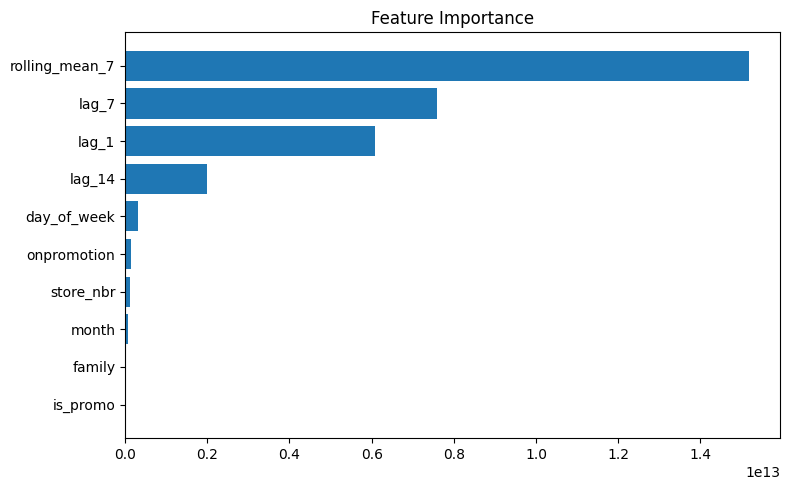

In [ ]:
import matplotlib.pyplot as plt

# 特徴量重要度をデータフレーム化
fi = pd.DataFrame({
    'feature': lgb_model.feature_names_in_,
    'importance': lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

display(fi)

# 可視化
plt.figure(figsize=(8, 5))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

- 特徴量重要度をgain（損失減少量）ベースで確認したところ、rolling_mean_7やlag_7、lag_1といった時系列特徴量が特に高い重要度を示した。

- この結果から、売上は直近のトレンドや過去の売上パターンに強く依存していることが示唆される。

- 一方で、カレンダー情報（day_of_week, month）や販促情報（onpromotion）、店舗情報（store_nbr）、商品カテゴリ（family）、販促有無（is_promo）などは相対的に重要度が低く、時系列特徴量を補助する役割を担っていると考えられる。

- 特に販促情報についてはEDAでは売上への影響が確認されたが、
モデル上では重要度は限定的であった。
これは販促の影響が過去売上（lag特徴量やrolling特徴量）に既に反映されているため、
追加的な情報としての寄与が小さくなった可能性がある。

### 4.5 ハイパーパラメータ調整

LightGBMの性能改善を目的として、主要なハイパーパラメータをランダムサーチで調整する。  
グリッドサーチは全組み合わせを試すため計算コストが高くなりやすいため、本分析では効率的に探索できるRandomizedSearchCVを採用する。  なお、計算時間を考慮し直近1年分の学習データを用いて探索を行う。

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# ===== チューニング用データを作成（直近1年分） =====
tune_start_date = train_df['date'].max() - pd.Timedelta(days=365)
tune_df = train_df[train_df['date'] >= tune_start_date].copy()

X_tune = tune_df[features]
y_tune = tune_df[target]

# 時系列の順序を保ったCV
tscv = TimeSeriesSplit(n_splits=2)

# 探索を行うパラメータ範囲
param_dist = {
    'n_estimators': [500, 800, 1000],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# ベースとなるLightGBM
lgb_estimator = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=1
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=lgb_estimator,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 学習
random_search.fit(
    X_tune,
    y_tune,
    categorical_feature=['store_nbr', 'family']
)

# 最適なパラメータの組み合わせと、ベストスコアを表示
print(f'Best Params: {random_search.best_params_}')
print(f'Best Score(MAE): {-random_search.best_score_:.4f}')


Fitting 2 folds for each of 10 candidates, totalling 20 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.123455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 650430, number of used features: 10
[LightGBM] [Info] Start training from score 457.403194
Best Params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best Score(MAE): 83.3280


ランダムサーチで得られた最適なハイパーパラメータを用いて、LightGBMを再学習する。  
最終評価には、これまでと同じテストデータを用いる。

In [ ]:
# Random Searchで得られた最適パラメータ
best_params = random_search.best_params_

# 最適パラメータでモデルを定義
tuned_lgb_model = lgb.LGBMRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

# 最適パラメータで再学習
tuned_lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='l1',
    categorical_feature=['store_nbr', 'family'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

# テストデータで予測
tuned_lgb_pred = tuned_lgb_model.predict(X_test)

# テストデータでMAE評価
tuned_lgb_mae = mean_absolute_error(y_test, tuned_lgb_pred)

print(f'Baseline MAE      : {baseline_mae:.4f}')
print(f'LightGBM MAE      : {lgb_mae:.4f}')
print(f'Tuned LightGBM MAE: {tuned_lgb_mae:.4f}')
print(f'ベースラインからの改善量: {(baseline_mae - tuned_lgb_mae):.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.465611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1331
[LightGBM] [Info] Number of data points in the train set: 2762100, number of used features: 10
[LightGBM] [Info] Start training from score 349.697726
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 75.3606	valid_0's l2: 94210.3
Early stopping, best iteration is:
[111]	valid_0's l1: 75.0322	valid_0's l2: 94016.7
Baseline MAE      : 87.7699
LightGBM MAE      : 67.0806
Tuned LightGBM MAE: 66.6672
ベースラインからの改善量: 21.1028


- RandomizedSearchCVにより得られた最適なハイパーパラメータを用いてLightGBMモデルを再学習した結果、テストデータにおけるMAEは以下の通りとなった。

  -- Baseline MAE：87.77  
  -- LightGBM MAE：67.08  
  -- Tuned LightGBM MAE：66.67  

- ハイパーパラメータ調整により、LightGBM単体と比較してわずかながら精度の改善が確認された。  
- 今回の最適化ではlearning_rateは変化せず、主にnum_leavesやcolsample_bytreeといったパラメータが調整され、汎化性能が向上したと考えられる。
- 一方で改善幅は限定的であり、もともとの特徴量設計が精度に大きく寄与していることが示唆される。  
したがって、本分析においてはハイパーパラメータ調整よりも特徴量設計の影響が相対的に大きいと考えられる。

### 4.6 SHAPによるモデル解釈

LightGBMモデルの予測結果をより詳細に解釈するため、SHAPを用いて各特徴量の寄与を確認する。

特徴量重要度では、どの特徴量がモデル内で重要視されたかは分かるが、各特徴量が予測値を押し上げる方向に働いたのか、押し下げる方向に働いたのかまでは分かりにくい。

そこでSHAPを用いて、特徴量ごとの予測への影響（方向と大きさ）を可視化する。

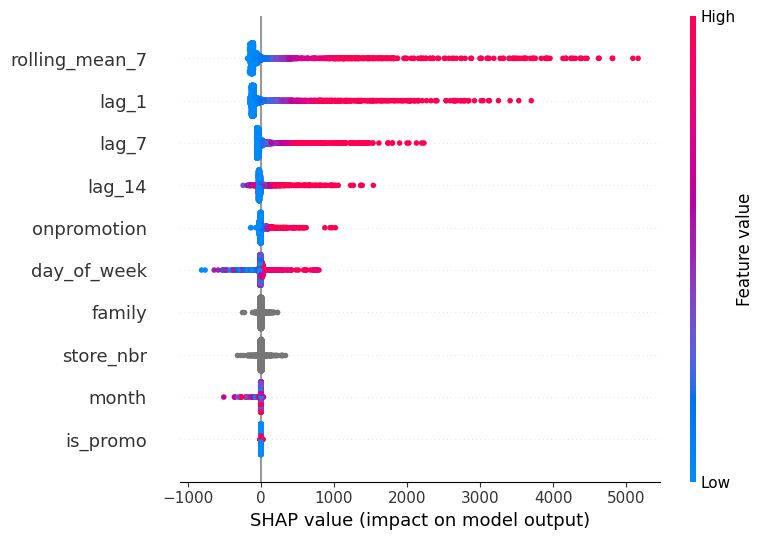

In [ ]:
import shap

# SHAPは計算量が大きいため、テストデータから一部をサンプリング
X_shap = X_test.sample(n=5000, random_state=42)

# LightGBMモデルに対してTreeExplainerを使用（説明器の作成）
explainer = shap.TreeExplainer(tuned_lgb_model)

# SHAP値を計算
shap_values = explainer.shap_values(X_shap)

# SHAP summary plotを可視化
shap.summary_plot(shap_values, X_shap)

- SHAPによる可視化の結果、rolling_mean_7やlag_1、lag_7といった時系列特徴量が予測に対して大きな影響を与えていることが確認された。

- 特に、これらの特徴量の値が高い場合には予測値を押し上げ、低い場合には押し下げる傾向が見られ、売上が直近のトレンドや過去の売上に強く依存していることが改めて示唆された。

- 一方で、販促情報（onpromotion）や曜日情報（day_of_week）は一定の影響を持つものの、時系列特徴量と比較すると寄与は限定的であった。

- また、商品カテゴリ（family）や店舗情報（store_nbr）、販促有無（is_promo）は影響が小さく、主に補助的な役割を果たしていると考えられる。

### 4.7 予測結果の可視化

モデルの予測精度を直感的に把握するため、テストデータにおける実測値と予測値を時系列で比較する。

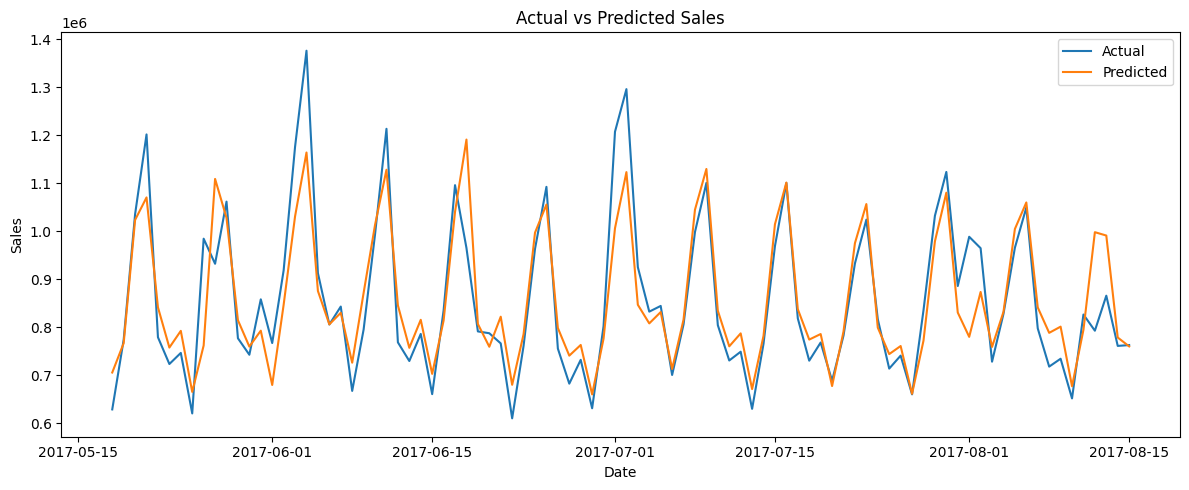

In [ ]:
# 日別で集計して比較
pred_df = pd.DataFrame({
    'date': test_df['date'],
    'actual': y_test,
    'pred': tuned_lgb_pred
})

daily_compare = pred_df.groupby('date').sum()

# 可視化
plt.figure(figsize=(12,5))
plt.plot(daily_compare.index, daily_compare['actual'], label='Actual')
plt.plot(daily_compare.index, daily_compare['pred'], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

- 実測値と予測値を比較すると、全体的なトレンドや週次の周期性は概ね再現されていることが確認できる。

- 一方で、売上のピークや急激な変動においては、予測値がやや過小評価となる傾向が見られた。
- これは、モデルが過去売上（lag特徴量やrolling特徴量）に強く依存しているため、突発的な需要増加や外部要因による変動を十分に捉えきれていない可能性がある。

- 以上より、本モデルは安定した予測性能を持つ一方で、極端な変動に対しては改善の余地があると考えられるため、今後は祝日データやイベント情報などの外部特徴量を追加することでさらなる精度向上が期待される。

### 4.8 残差分析

モデルの予測誤差の分布を確認するため、残差（実測値−予測値）をヒストグラムで可視化する。

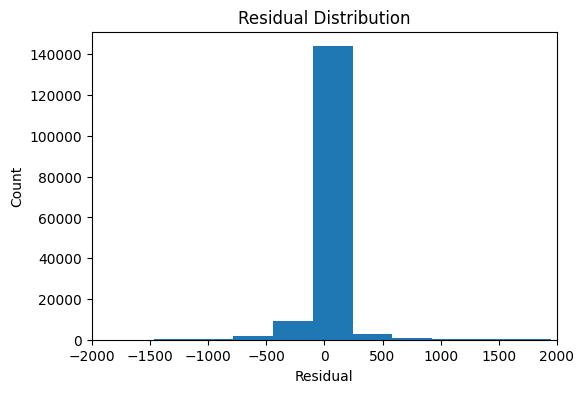

In [ ]:
# 残差（実測 - 予測）を計算
residuals = y_test - tuned_lgb_pred

# ヒストグラムで可視化
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.xlim(-2000, 2000)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()

- 残差分布は0付近に集中しており、全体として大きなバイアスは見られなかった。

- 一方で、一部に大きな誤差が存在しており、突発的な需要変動を十分に捉えきれていない可能性がある。

## 5. まとめ

- 本分析では、店舗・商品カテゴリごとの売上データに対して需要予測モデルを構築した。

- その結果、LightGBMを用いることでベースラインと比較して予測精度の改善が確認された。

- また、特徴量重要度やSHAPによる解釈から、売上は主に過去の売上（lag特徴量やrolling特徴量）に強く依存していることが示された。

- 一方で、ピーク時など一部のデータでは予測誤差が大きくなる傾向があり、外部要因を十分に捉えきれていない可能性が示唆された。

- 祝日やイベントなどの外部特徴量を追加することでピーク時の予測精度向上が期待されるが、本分析ではまず過去売上に基づくモデルの構築に注力した。